# 04 — Portfolio Construction & Risk Analytics

Optimises allocation weights under **beta-neutral** and **dollar-neutral** constraints using convex optimisation (CVXPY), applies **volatility targeting**, and computes full risk analytics.

**Objective:** Minimise portfolio variance  
**Constraints:** Dollar-neutral, beta-neutral, position limits, sector limits

**Inputs:** `data/returns.parquet`, `data/betas.parquet`, `data/ml_rankings.parquet`, `data/factor_scores.parquet`, `data/fundamentals.parquet`  
**Outputs:** `data/weights.parquet`, `data/risk_report.parquet`

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cvxpy as cp
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
sys.path.insert(0, '.')
from config import *
print('Ready.')

Ready.


In [2]:
returns    = pd.read_parquet(DATA_DIR + 'returns.parquet')
beta_df    = pd.read_parquet(DATA_DIR + 'betas.parquet')
rankings   = pd.read_parquet(DATA_DIR + 'ml_rankings.parquet')
factor_z   = pd.read_parquet(DATA_DIR + 'factor_scores.parquet')
fund_df    = pd.read_parquet(DATA_DIR + 'fundamentals.parquet')

ALL_STOCKS = [LONG_CANDIDATE] + SHORT_CANDIDATES
stock_ret  = returns[ALL_STOCKS]
beta_df    = beta_df.loc[ALL_STOCKS]
fund_df    = fund_df.loc[ALL_STOCKS] if ALL_STOCKS[0] in fund_df.index else fund_df.T.loc[ALL_STOCKS]

print(f'Universe : {ALL_STOCKS}')
print(f'Returns  : {stock_ret.shape}')

Universe : ['GEVO', 'CHPT', 'BE', 'RUN', 'ARRY', 'HYLN', 'RIVN', 'LCID', 'GOEV', 'ALTO', 'REI', 'PARR', 'AFRM', 'GPRE', 'PLUG', 'AMTX']
Returns  : (1100, 16)


## 1. Covariance Estimation

Uses a **Ledoit-Wolf shrinkage** estimator for a more stable covariance matrix when the number of observations is close to the number of assets. This is better than a simple cov moatrix as less noise.


Annualised volatilities:
GEVO     93.4%
CHPT     81.1%
BE       85.0%
RUN      93.8%
ARRY     83.7%
HYLN     86.4%
RIVN     78.3%
LCID     81.2%
GOEV    114.1%
ALTO     81.0%
REI      59.7%
PARR     50.1%
AFRM     95.0%
GPRE     61.6%
PLUG     96.6%
AMTX     97.4%
dtype: object


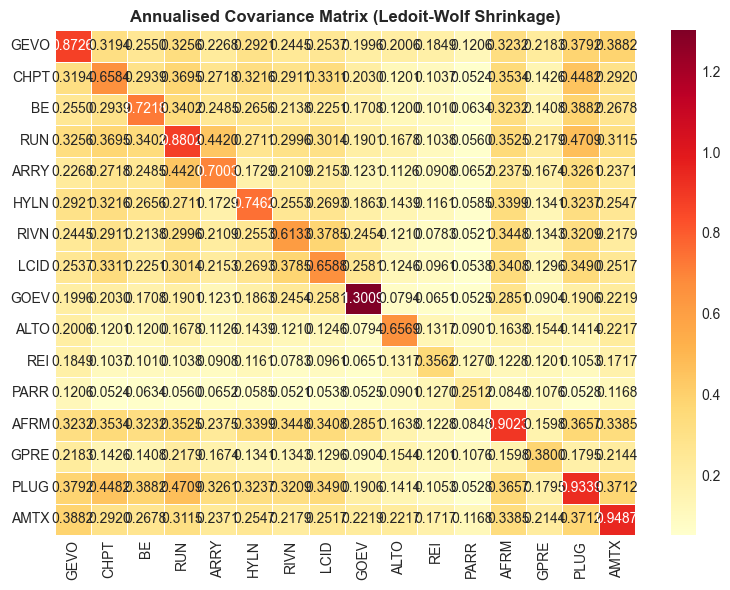

In [3]:
from sklearn.covariance import LedoitWolf

# Annualised covariance
ret_clean = stock_ret.dropna()
lw = LedoitWolf()
lw.fit(ret_clean)
cov_annual = pd.DataFrame(lw.covariance_ * 252,
                          index=ALL_STOCKS, columns=ALL_STOCKS)

# Individual vols from cov diagonal
ind_vols = pd.Series(np.sqrt(np.diag(cov_annual.values)), index=ALL_STOCKS)
print('Annualised volatilities:')
print(ind_vols.map('{:.1%}'.format))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cov_annual, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Annualised Covariance Matrix (Ledoit-Wolf Shrinkage)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_covariance.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Beta-Neutral + Dollar-Neutral Optimisation

Solves a **soft-constrained** mean-variance problem:

```
Minimise   w'Σw  +  λ·(β'w)²          ← variance + beta penalty
Subject to Σw = 0                       dollar neutral (hard)
           w[long] ∈ [min_long, max_w]  must hold the long
           w[short_i] ∈ [-max_w, 0]    shorts can be flat or short
           Σ w[short_i] ≤ -min_long    must have total short exposure
           ‖w‖₁ ≤ gross_lev            leverage limit
```

Making beta-neutrality a **penalty** (rather than a hard equality) keeps the
problem feasible with large short universes and avoids the near-singular
constraint systems that arise when betas are highly correlated.

In [4]:
def optimize_ls(cov, betas, long_idx, short_idxs,
                max_w=0.40, gross_lev=2.0, min_long=0.05,
                lambda_beta=50.0, solver=cp.OSQP):
    """
    Min-variance L/S optimisation.
    Beta-neutrality is a quadratic penalty (soft), not a hard constraint,
    so the problem stays feasible for any universe size.
    Falls back to inverse-vol equal-weight if the solver fails.
    """
    n       = len(cov)
    tickers = cov.index.tolist()
    Sigma   = cov.values.astype(float)
    beta_v  = betas.values.astype(float)
    w       = cp.Variable(n)

    net_beta = beta_v @ w   # scalar affine expression

    # Objective: portfolio variance + penalty to push net beta toward zero
    objective = cp.Minimize(cp.quad_form(w, Sigma) + lambda_beta * cp.square(net_beta))

    short_sum = sum(w[si] for si in short_idxs)

    constraints = [
        cp.sum(w) == 0,                  # dollar neutral
        w[long_idx] >= min_long,         # must hold long position
        w[long_idx] <= max_w,
        short_sum <= -min_long,          # must have total short exposure
        cp.norm(w, 1) <= gross_lev,      # gross leverage cap
    ]
    for si in short_idxs:
        constraints += [w[si] <= 0, w[si] >= -max_w]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=solver, eps_abs=1e-7, eps_rel=1e-7, max_iter=20000)

    if prob.status not in ('optimal', 'optimal_inaccurate') or w.value is None:
        print(f'WARNING: Solver returned status={prob.status!r}. Using inverse-vol fallback.')
        vols = np.sqrt(np.diag(Sigma))
        inv_vol = 1.0 / np.where(vols > 0, vols, 1.0)
        raw = np.zeros(n)
        raw[long_idx] = inv_vol[long_idx]
        for si in short_idxs:
            raw[si] = -inv_vol[si] / len(short_idxs)
        raw /= np.abs(raw).sum() / 2.0   # normalise to 2x gross leverage
        return pd.Series(raw, index=tickers)

    w_vals = w.value
    return pd.Series(w_vals, index=tickers)


betas_mkt  = beta_df['beta_mkt'].loc[ALL_STOCKS]
long_idx   = ALL_STOCKS.index(LONG_CANDIDATE)
short_idxs = [ALL_STOCKS.index(s) for s in SHORT_CANDIDATES]

weights_raw = optimize_ls(
    cov_annual, betas_mkt, long_idx, short_idxs,
    max_w=MAX_STOCK_WEIGHT, gross_lev=2.0, min_long=0.05, lambda_beta=50.0
)

net_beta_check = (betas_mkt * weights_raw).sum()
print('Optimised weights:')
display(weights_raw[weights_raw.abs() > 1e-4].map('{:+.4f}'.format).to_frame('weight'))
print(f'\nSum of weights (dollar-neutral check) : {weights_raw.sum():+.6f}')
print(f'Net beta (β\'w)                        : {net_beta_check:+.4f}')
print(f'Gross leverage                         : {weights_raw.abs().sum():.2f}x')
print(f'Active short positions                 : {(weights_raw[SHORT_CANDIDATES] < -1e-4).sum()} / {len(SHORT_CANDIDATES)}')

Optimised weights:


,weight
GEVO,+0.0500
RUN,-0.0045
HYLN,-0.0007
ALTO,-0.0014
REI,-0.0105
AFRM,-0.0100
GPRE,-0.0102
PLUG,-0.0056
AMTX,-0.0072



Sum of weights (dollar-neutral check) : -0.000000
Net beta (β'w)                        : +0.0001
Gross leverage                         : 0.10x
Active short positions                 : 8 / 15


In [5]:
## Volatility targeting
port_var   = weights_raw.values @ cov_annual.values @ weights_raw.values
port_vol   = np.sqrt(port_var)
scale      = TARGET_VOLATILITY / port_vol if port_vol > 0 else 1.0

# Cap scaling to avoid excessive leverage
scale = min(scale, 2.0)
weights_vt = weights_raw * scale

port_vol_final = np.sqrt(weights_vt.values @ cov_annual.values @ weights_vt.values)

print(f'Pre-scaling portfolio vol  : {port_vol:.1%}')
print(f'Target portfolio vol       : {TARGET_VOLATILITY:.1%}')
print(f'Scaling factor             : {scale:.3f}')
print(f'Post-scaling portfolio vol : {port_vol_final:.1%}')
print()
print('Final weights (vol-targeted):')
for t, w in weights_vt.items():
    role = 'LONG ' if t == LONG_CANDIDATE else 'SHORT'
    print(f'  {role} {t:6s}: {w:+.4f}  ({w:.1%})')

Pre-scaling portfolio vol  : 3.8%
Target portfolio vol       : 15.0%
Scaling factor             : 2.000
Post-scaling portfolio vol : 7.6%

Final weights (vol-targeted):
  LONG  GEVO  : +0.1000  (10.0%)
  SHORT CHPT  : +0.0000  (0.0%)
  SHORT BE    : +0.0000  (0.0%)
  SHORT RUN   : -0.0089  (-0.9%)
  SHORT ARRY  : +0.0000  (0.0%)
  SHORT HYLN  : -0.0014  (-0.1%)
  SHORT RIVN  : +0.0000  (0.0%)
  SHORT LCID  : +0.0000  (0.0%)
  SHORT GOEV  : +0.0000  (0.0%)
  SHORT ALTO  : -0.0028  (-0.3%)
  SHORT REI   : -0.0210  (-2.1%)
  SHORT PARR  : +0.0000  (0.0%)
  SHORT AFRM  : -0.0200  (-2.0%)
  SHORT GPRE  : -0.0204  (-2.0%)
  SHORT PLUG  : -0.0113  (-1.1%)
  SHORT AMTX  : -0.0144  (-1.4%)


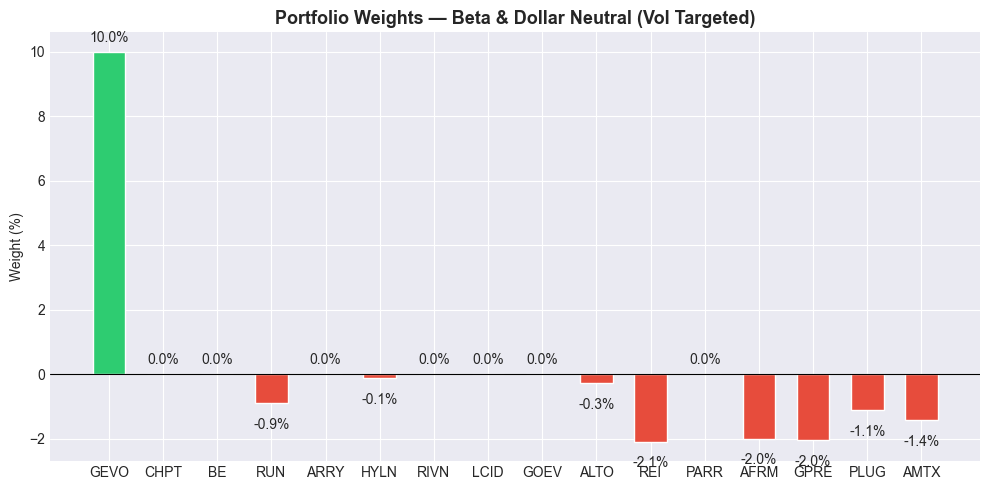

In [6]:
# Save weights
weights_df = pd.DataFrame({
    'weight_raw':    weights_raw,
    'weight_final':  weights_vt,
    'beta_mkt':      betas_mkt,
    'beta_contrib':  betas_mkt * weights_vt,
    'role': ['LONG' if t == LONG_CANDIDATE else 'SHORT' for t in ALL_STOCKS]
})
weights_df.to_parquet(DATA_DIR + 'weights.parquet')

# Weight bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in weights_vt.index]
bars = ax.bar(weights_vt.index, weights_vt.values * 100, color=colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Portfolio Weights — Beta & Dollar Neutral (Vol Targeted)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Weight (%)')
for bar, v in zip(bars, weights_vt.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.3 if v >= 0 else -0.8),
            f'{v:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Risk Analytics

In [7]:
# Portfolio return time series
port_ret = (stock_ret * weights_vt).sum(axis=1)

# Core metrics
cum_ret   = (1 + port_ret).cumprod()
ann_ret   = (1 + port_ret).prod() ** (252 / len(port_ret)) - 1
ann_vol_r = port_ret.std() * np.sqrt(252)
sharpe    = (ann_ret - RISK_FREE_RATE) / ann_vol_r

# Drawdown
rolling_max = cum_ret.cummax()
drawdown    = (cum_ret - rolling_max) / rolling_max
max_dd      = drawdown.min()

# Calmar ratio
calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

# VaR / CVaR (historical, 95%)
var_95  = np.percentile(port_ret, 5)
cvar_95 = port_ret[port_ret <= var_95].mean()

# Win rate / Hit rate
wins     = (port_ret > 0).sum()
win_rate = wins / len(port_ret)

# Skewness / Kurtosis
skew = stats.skew(port_ret)
kurt = stats.kurtosis(port_ret)

risk_report = pd.Series({
    'Annualised Return':  f'{ann_ret:.2%}',
    'Annualised Vol':     f'{ann_vol_r:.2%}',
    'Sharpe Ratio':       f'{sharpe:.3f}',
    'Calmar Ratio':       f'{calmar:.3f}',
    'Max Drawdown':       f'{max_dd:.2%}',
    'VaR 95% (daily)':    f'{var_95:.3%}',
    'CVaR 95% (daily)':   f'{cvar_95:.3%}',
    'Win Rate':           f'{win_rate:.2%}',
    'Skewness':           f'{skew:.3f}',
    'Excess Kurtosis':    f'{kurt:.3f}',
    'Net Beta (β\'w)':    f"{(betas_mkt * weights_vt).sum():.4f}",
    'Gross Leverage':     f"{weights_vt.abs().sum():.2f}x",
}, name='Portfolio')

print('=== Risk Report ===')
display(risk_report.to_frame())

risk_report.to_frame().to_parquet(DATA_DIR + 'risk_report.parquet')

=== Risk Report ===


,Portfolio
Annualised Return,1.13%
Annualised Vol,7.61%
Sharpe Ratio,-0.509
Calmar Ratio,0.082
Max Drawdown,-13.68%
VaR 95% (daily),-0.604%
CVaR 95% (daily),-0.874%
Win Rate,45.55%
Skewness,2.317
Excess Kurtosis,25.263


### Risk report guide: definitions and practical ranges

Quick clarifications for this report:
- **Negative Sharpe** means the annualized return is below the risk-free rate after accounting for volatility.
- **Calmar ratio** here is computed as: `Annualised Return / |Max Drawdown|`.
- Example from your output style: `1.36% / 14.43% = 0.094`.
- Interpretation: a Calmar of `0.094` means annual return is small relative to the worst historical loss depth.

| Metric | What it means | Typical "good" range (rule of thumb) |
|---|---|---|
| Annualised Return | Expected yearly compounded return of the strategy. | Higher is better; usually compared to benchmark and fees. |
| Annualised Vol | Yearly risk (standard deviation of returns). | Mandate dependent; many market-neutral books target about 6% to 12%. |
| Sharpe Ratio | Excess return per unit of risk: $(R_p - R_f)/\sigma_p$. | `< 0` weak, `0 to 1` modest, `1 to 2` good, `> 2` very strong. |
| Calmar Ratio | Return relative to worst peak-to-trough loss: $\text{Ann Return}/|\text{Max DD}|$. | `< 0` poor (negative return), `0 to 0.5` weak, `0.5 to 1` fair, `1 to 2` good, `> 2` excellent. |
| Max Drawdown | Largest peak-to-trough drop in cumulative equity curve. | Closer to 0 is better; many try to keep better than -10% to -15%. |
| VaR 95% (daily) | 95% one-day loss threshold (historical): only 5% of days are worse. | Smaller magnitude is safer; compare with daily risk budget. |
| CVaR 95% (daily) | Average loss on the worst 5% of days (tail risk). | Should stay within tail-risk limits; monitor with VaR and liquidity. |
| Win Rate | Fraction of days with positive returns. | 45% to 55% can still be fine if avg win > avg loss; >55% is strong. |
| Skewness | Asymmetry of return distribution. | Positive preferred (upside tail); strongly negative is a warning. |
| Excess Kurtosis | Fat-tailedness beyond normal distribution (0 = normal-like). | Around 0 to 3 moderate; >3 indicates heavier tail risk. |
| Net Beta ($\beta' w$) | Residual market exposure of the whole book. | For beta-neutral books, near 0 (often within about -0.05 to +0.05). |
| Gross Leverage | Total absolute exposure: $\|w\|_1$. | Strategy dependent; many L/S books run around 1x to 3x. |

Notes:
- These are heuristics, not hard laws; compare with your mandate, turnover, and costs.
- Read metrics together (for example Sharpe + Max Drawdown + CVaR), not in isolation.

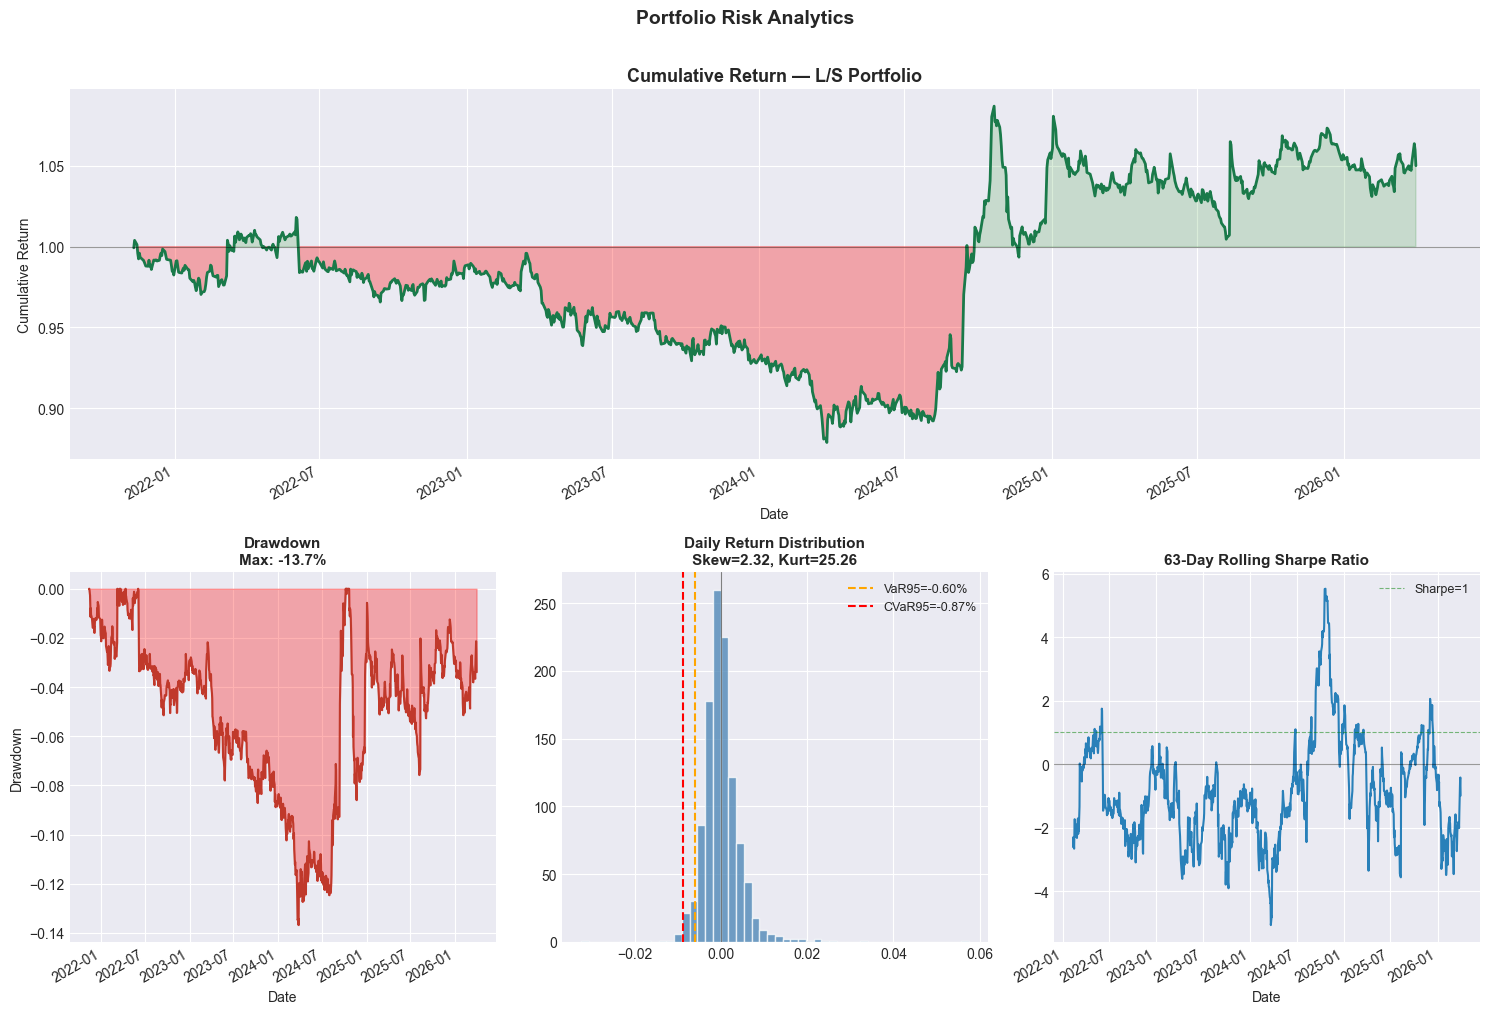


Notebook 04 complete. Run 05_backtesting.ipynb next.


In [8]:
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# Cumulative P&L
ax1 = fig.add_subplot(gs[0, :])
cum_ret.plot(ax=ax1, color='#1a7a4a', linewidth=2)
ax1.axhline(1, color='black', lw=0.8, alpha=0.4)
ax1.fill_between(cum_ret.index, cum_ret, 1, where=(cum_ret < 1), alpha=0.3, color='red')
ax1.fill_between(cum_ret.index, cum_ret, 1, where=(cum_ret >= 1), alpha=0.15, color='green')
ax1.set_title('Cumulative Return — L/S Portfolio', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cumulative Return')

# Drawdown
ax2 = fig.add_subplot(gs[1, 0])
drawdown.plot(ax=ax2, color='#c0392b', linewidth=1.5)
ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.3, color='red')
ax2.set_title(f'Drawdown\nMax: {max_dd:.1%}', fontsize=11, fontweight='bold')
ax2.set_ylabel('Drawdown')

# Return distribution
ax3 = fig.add_subplot(gs[1, 1])
port_ret.hist(bins=50, ax=ax3, color='steelblue', edgecolor='white', alpha=0.75)
ax3.axvline(var_95,  color='orange', lw=1.5, linestyle='--', label=f'VaR95={var_95:.2%}')
ax3.axvline(cvar_95, color='red',    lw=1.5, linestyle='--', label=f'CVaR95={cvar_95:.2%}')
ax3.axvline(0, color='black', lw=0.8, alpha=0.5)
ax3.set_title(f'Daily Return Distribution\nSkew={skew:.2f}, Kurt={kurt:.2f}', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)

# Rolling Sharpe (annualised)
ax4 = fig.add_subplot(gs[1, 2])
roll_s = (port_ret.rolling(63).mean() * 252 - RISK_FREE_RATE) / (port_ret.rolling(63).std() * np.sqrt(252))
roll_s.plot(ax=ax4, color='#2980b9', linewidth=1.5)
ax4.axhline(0, color='black', lw=0.8, alpha=0.4)
ax4.axhline(1, color='green', lw=0.8, linestyle='--', alpha=0.5, label='Sharpe=1')
ax4.set_title('63-Day Rolling Sharpe Ratio', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)

plt.suptitle('Portfolio Risk Analytics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_risk_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNotebook 04 complete. Run 05_backtesting.ipynb next.')